In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn


In [2]:

import os
import glob
import time
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [3]:
df = pd.read_csv("Combined_Plant_Data_Cleaned.csv")
df.head()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106078 entries, 0 to 106077
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DATE_TIME            106078 non-null  object 
 1   PLANT_ID             106078 non-null  int64  
 2   DC_POWER             106078 non-null  float64
 3   AC_POWER             106078 non-null  float64
 4   DAILY_YIELD          106078 non-null  float64
 5   TOTAL_YIELD          106078 non-null  float64
 6   AMBIENT_TEMPERATURE  106078 non-null  float64
 7   MODULE_TEMPERATURE   106078 non-null  float64
 8   IRRADIATION          106078 non-null  float64
 9   Hour                 106078 non-null  int64  
 10  DayOfWeek            106078 non-null  int64  
 11  Month                106078 non-null  int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 9.7+ MB


In [4]:
df = pd.read_csv("train data.csv", sep=';')
df.head()



,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,3.464132,3.464132,3.776515,3.433125,0.000054,3.776515,3.433125,0.000054,3.755050,3.755050,...,514.369415,509.002655,169.603373,660,22,0.343390,0.343390,1.332270e-14,5.773160e-15,1
1,2.244766,2.244766,2.611714,2.210978,0.000350,2.611714,2.210978,0.000350,2.572122,2.572122,...,521.970593,503.241431,116.954097,450,15,0.400736,0.400736,1.554310e-14,0.000000e+00,1
2,3.878360,3.878360,4.101282,3.854098,0.000010,4.101282,3.854098,0.000010,4.094577,4.094577,...,511.837039,509.378912,184.213307,720,24,0.247183,0.247183,2.131630e-14,7.105430e-15,1
3,2.816389,2.816389,3.285793,2.758149,0.000192,3.285793,2.758149,0.000192,3.247759,3.247759,...,518.028478,507.378348,147.283635,570,19,0.527644,0.527644,1.199040e-14,1.332270e-14,1
4,1.238798,1.238798,5.455667,0.141519,0.001153,5.455667,0.141519,0.001153,5.465640,5.465640,...,500.827418,500.127036,238.608844,960,32,5.314147,5.314147,2.442490e-14,2.042810e-14,1


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   I1          600 non-null    float64
 1   I2          600 non-null    float64
 2   I1MAX       600 non-null    float64
 3   I1MIN       600 non-null    float64
 4   I1VAR       600 non-null    float64
 5   I2MAX       600 non-null    float64
 6   I2MIN       600 non-null    float64
 7   I2VAR       600 non-null    float64
 8   I3          600 non-null    float64
 9   I4          600 non-null    float64
 10  I3max       600 non-null    float64
 11  I3min       600 non-null    float64
 12  I3var       600 non-null    float64
 13  I4MAX       600 non-null    float64
 14  I4MIN       600 non-null    float64
 15  I5          600 non-null    float64
 16  I6          600 non-null    float64
 17  Itotal1     600 non-null    float64
 18  Itotalmax1  600 non-null    float64
 19  Itotalmin1  600 non-null    f

In [6]:
train_df = pd.read_csv("train data.csv", sep=';')
test_df = pd.read_csv("test data.csv", sep=';')

print(train_df.shape, test_df.shape)
train_df.head()


(600, 31) (100, 31)


,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,3.464132,3.464132,3.776515,3.433125,0.000054,3.776515,3.433125,0.000054,3.755050,3.755050,...,514.369415,509.002655,169.603373,660,22,0.343390,0.343390,1.332270e-14,5.773160e-15,1
1,2.244766,2.244766,2.611714,2.210978,0.000350,2.611714,2.210978,0.000350,2.572122,2.572122,...,521.970593,503.241431,116.954097,450,15,0.400736,0.400736,1.554310e-14,0.000000e+00,1
2,3.878360,3.878360,4.101282,3.854098,0.000010,4.101282,3.854098,0.000010,4.094577,4.094577,...,511.837039,509.378912,184.213307,720,24,0.247183,0.247183,2.131630e-14,7.105430e-15,1
3,2.816389,2.816389,3.285793,2.758149,0.000192,3.285793,2.758149,0.000192,3.247759,3.247759,...,518.028478,507.378348,147.283635,570,19,0.527644,0.527644,1.199040e-14,1.332270e-14,1
4,1.238798,1.238798,5.455667,0.141519,0.001153,5.455667,0.141519,0.001153,5.465640,5.465640,...,500.827418,500.127036,238.608844,960,32,5.314147,5.314147,2.442490e-14,2.042810e-14,1


In [7]:
X_train = train_df.drop("class", axis=1)
y_train = train_df["class"]

X_test = test_df.drop("class", axis=1)
y_test = test_df["class"]


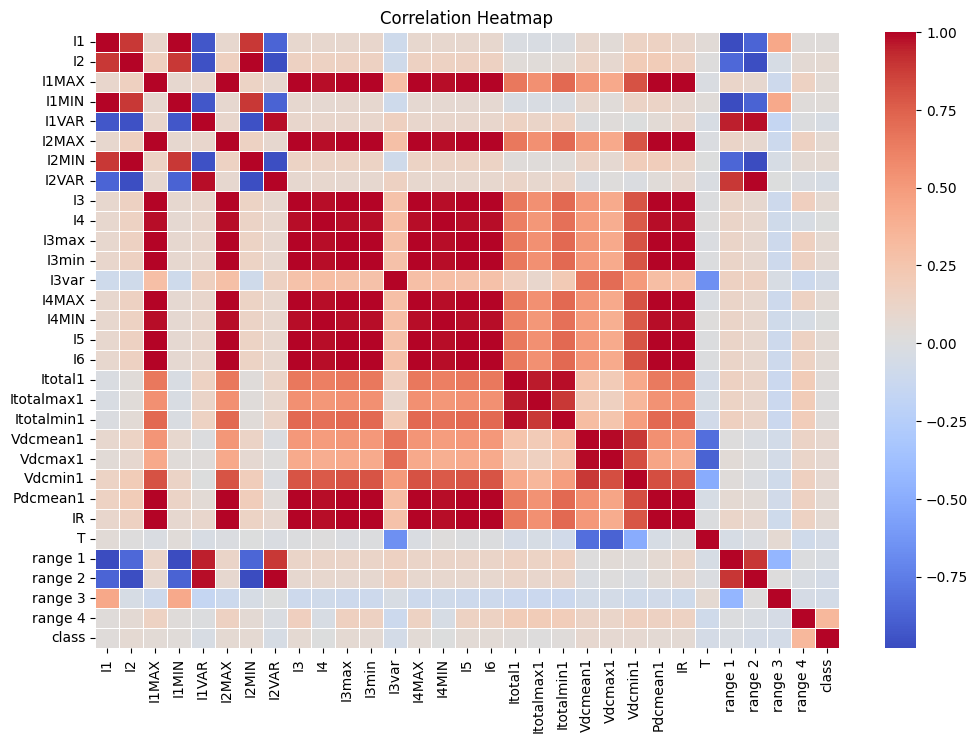

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


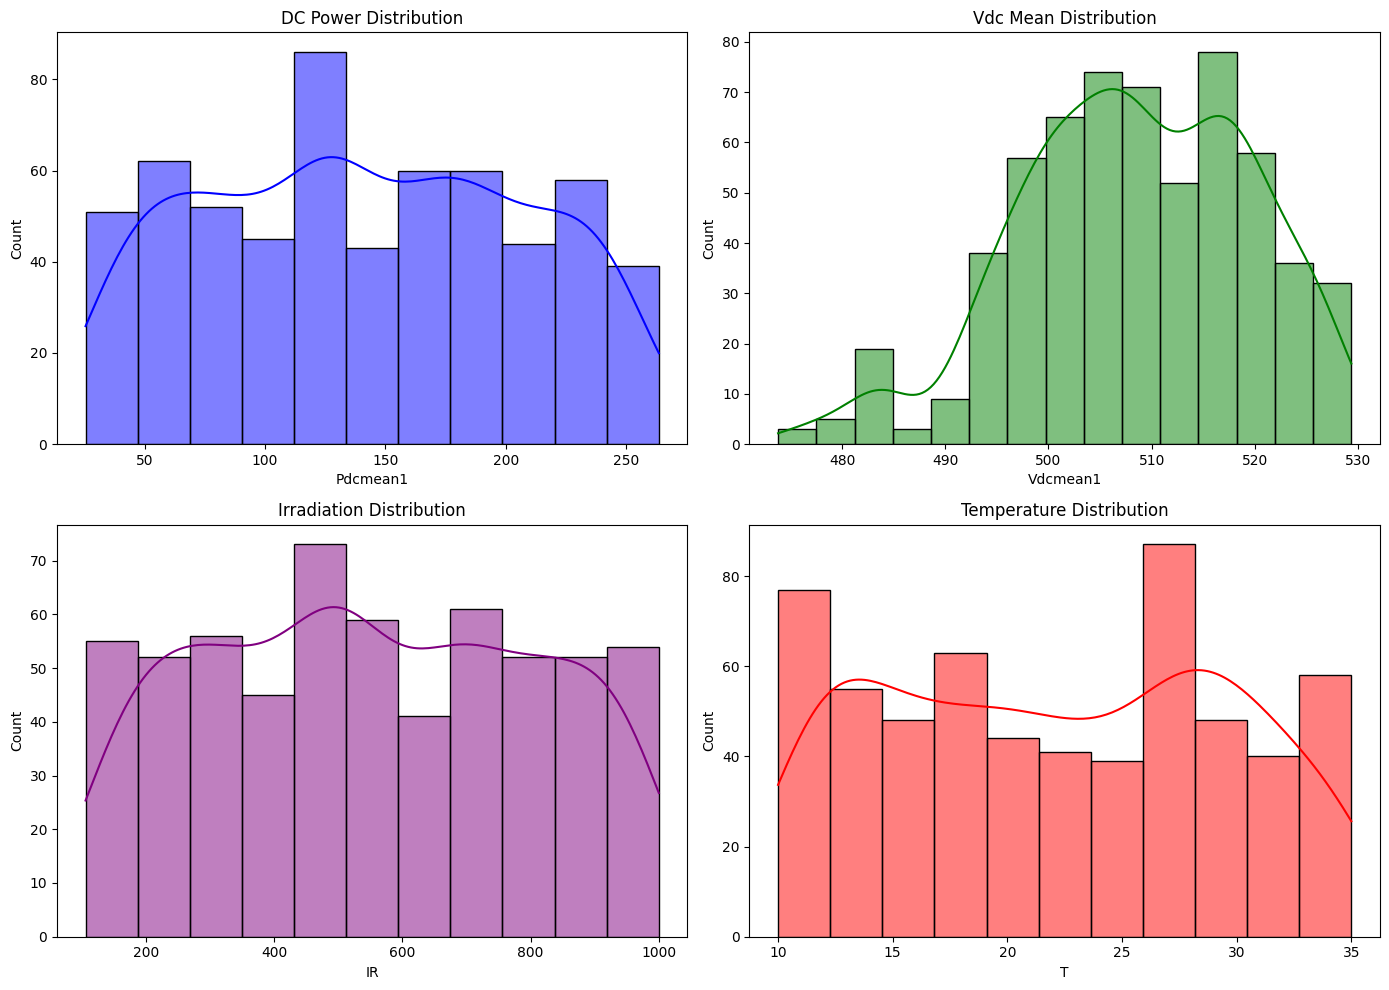

In [9]:
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
sns.histplot(train_df['Pdcmean1'], kde=True, color='blue')
plt.title("DC Power Distribution")

plt.subplot(2,2,2)
sns.histplot(train_df['Vdcmean1'], kde=True, color='green')
plt.title("Vdc Mean Distribution")

plt.subplot(2,2,3)
sns.histplot(train_df['IR'], kde=True, color='purple')
plt.title("Irradiation Distribution")

plt.subplot(2,2,4)
sns.histplot(train_df['T'], kde=True, color='red')
plt.title("Temperature Distribution")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

best_rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=42
)

# Train the tuned model
best_rf_model.fit(X_train, y_train)


RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_split=10,
                       n_estimators=400, random_state=42)

Accuracy: 0.87

Classification Report:

              precision    recall  f1-score   support

           0       0.78      1.00      0.88        25
           1       0.75      0.72      0.73        25
           2       1.00      0.76      0.86        25
           3       1.00      1.00      1.00        25

    accuracy                           0.87       100
   macro avg       0.88      0.87      0.87       100
weighted avg       0.88      0.87      0.87       100


Confusion Matrix:
 [[25  0  0  0]
 [ 7 18  0  0]
 [ 0  6 19  0]
 [ 0  0  0 25]]


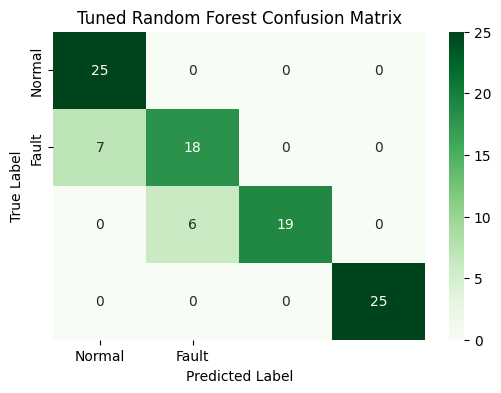

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_rf_pred = best_rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, best_rf_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, best_rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, best_rf_pred)
print("\nConfusion Matrix:\n", cm)

# Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Fault'],
            yticklabels=['Normal','Fault'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()


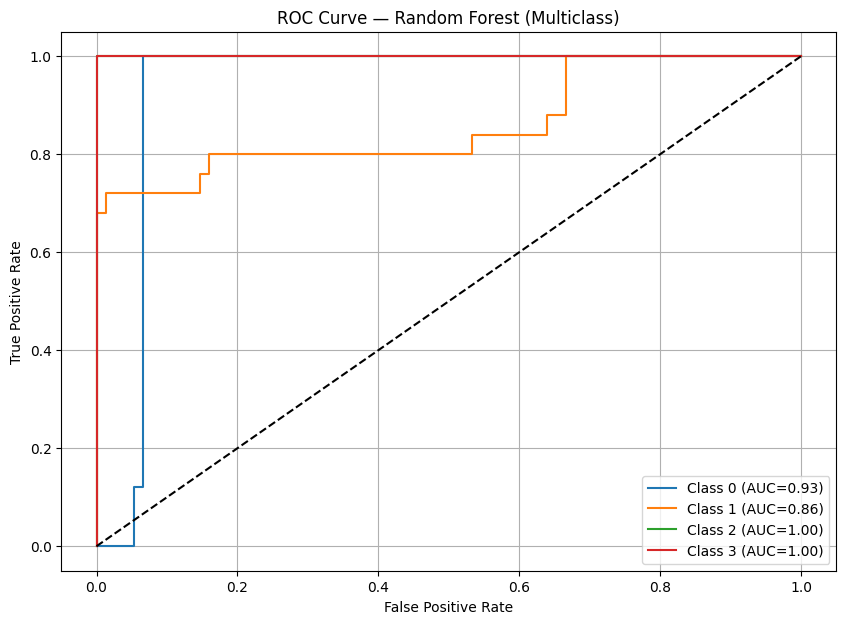

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]

rf_proba = best_rf_model.predict_proba(X_test)

plt.figure(figsize=(10,7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest (Multiclass)")
plt.legend()
plt.grid()
plt.show()


In [13]:
!pip install shap
import shap


In [14]:
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)


In [15]:
!pip install shap
import shap
shap.initjs()


In [16]:
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test.values)


/tmp/ipython-input-4113101819.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 0], X_test)


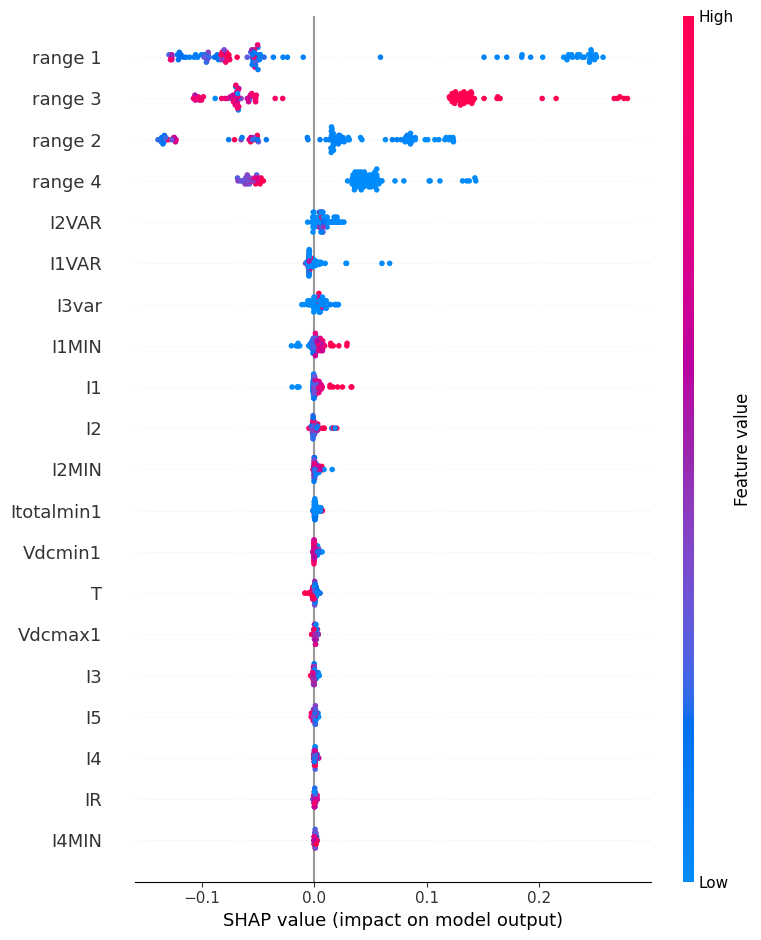

In [17]:
shap.summary_plot(shap_values[:, :, 1], X_test)

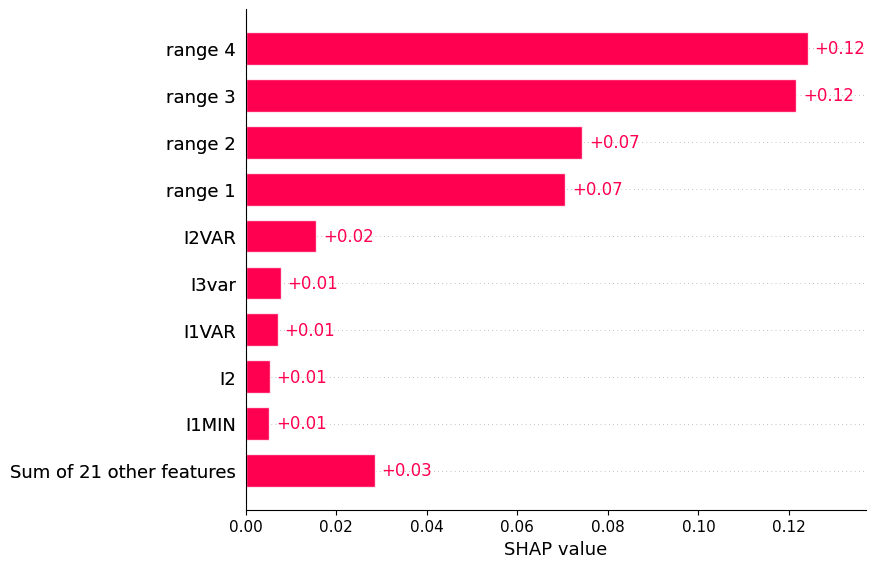

In [18]:
import numpy as np
import shap
import pandas as pd

# Calculate global feature importance by averaging absolute SHAP values across samples and classes
global_shap_values = np.mean(np.abs(shap_values), axis=(0, 2))

# Create an Explanation object suitable for shap.plots.bar
explanation_for_bar_plot = shap.Explanation(
    values=global_shap_values,
    feature_names=X_test.columns.tolist(),
    base_values=0 # For a global importance plot, 0 is a common neutral baseline
)

# Use shap.plots.bar with the Explanation object
shap.plots.bar(explanation_for_bar_plot)

In [19]:
# diagnostics for SHAP
import numpy as np
import shap
print("SHAP version:", shap.__version__)
print("Type of best_rf_model:", type(best_rf_model))
print("X_test shape:", X_test.shape)
print("X_test columns:", list(X_test.columns)[:10], " ... total", X_test.shape[1])

# Create explainer and compute shap values, capturing both old/new API outputs
try:
    explainer = shap.TreeExplainer(best_rf_model)
    shap_vals = explainer.shap_values(X_test)   # old style
    print("shap_values type:", type(shap_vals))
    if isinstance(shap_vals, list):
        print("number of classes (len list):", len(shap_vals))
        print("shape of first class array:", np.asarray(shap_vals[0]).shape)
    else:
        print("shap_values shape:", np.asarray(shap_vals).shape)
except Exception as e:
    print("explainer.shap_values() failed with:", repr(e))
    # try new API
    try:
        expl = explainer(X_test)
        print("explainer(X_test) returned:", type(expl))
        # explanation.data shape (samples x features) may be present
        if hasattr(expl, "values"):
            print("explainer returned .values shape:", np.asarray(expl.values).shape)
        if hasattr(expl, "values") and isinstance(expl.values, list):
            print("list len:", len(expl.values), "each shape:", [np.asarray(v).shape for v in expl.values])
    except Exception as e2:
        print("explainer(X_test) also failed with:", repr(e2))



SHAP version: 0.50.0
Type of best_rf_model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
X_test shape: (100, 30)
X_test columns: ['I1', 'I2', 'I1MAX', 'I1MIN', 'I1VAR', 'I2MAX', 'I2MIN', 'I2VAR', 'I3', 'I4']  ... total 30
shap_values type: <class 'numpy.ndarray'>
shap_values shape: (100, 30, 4)


/tmp/ipython-input-3546821005.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


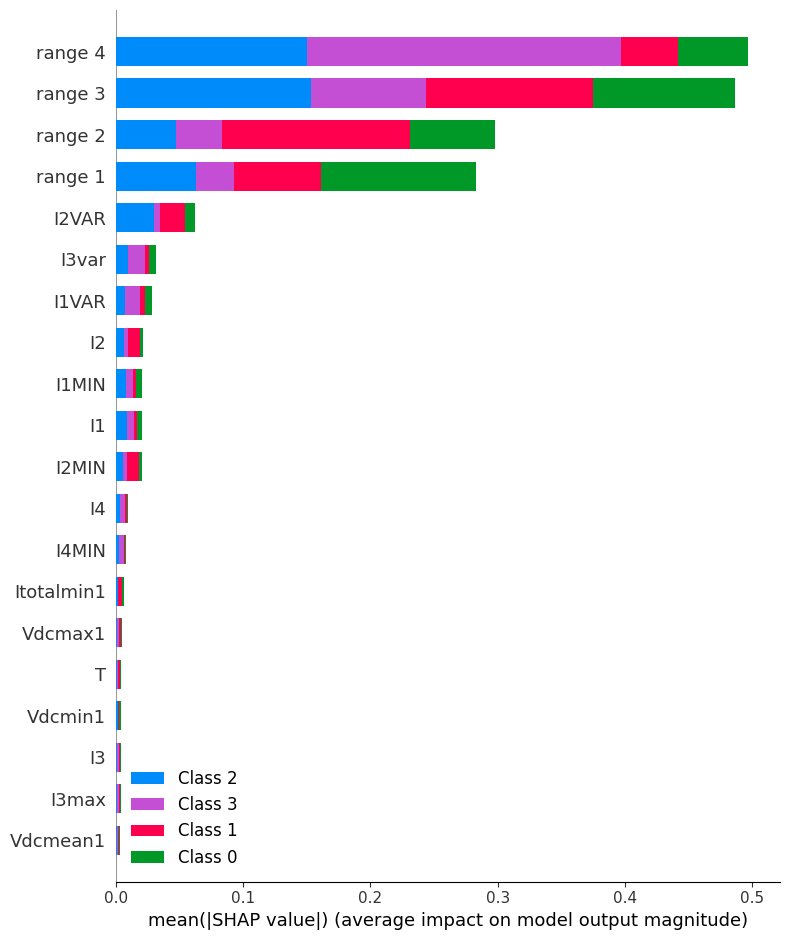

In [20]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [21]:
from sklearn.ensemble import GradientBoostingClassifier


In [22]:
best_gb_model = GradientBoostingClassifier(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)



In [23]:
best_gb_model.fit(X_train, y_train)


GradientBoostingClassifier(min_samples_leaf=2, n_estimators=200,
                           random_state=42, subsample=0.8)

In [24]:
gb_pred = best_gb_model.predict(X_test)



Gradient Boosting Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        25
           1       0.69      0.72      0.71        25
           2       1.00      0.48      0.65        25
           3       0.93      1.00      0.96        25

    accuracy                           0.80       100
   macro avg       0.83      0.80      0.79       100
weighted avg       0.83      0.80      0.79       100


Confusion Matrix:
 [[25  0  0  0]
 [ 7 18  0  0]
 [ 3  8 12  2]
 [ 0  0  0 25]]


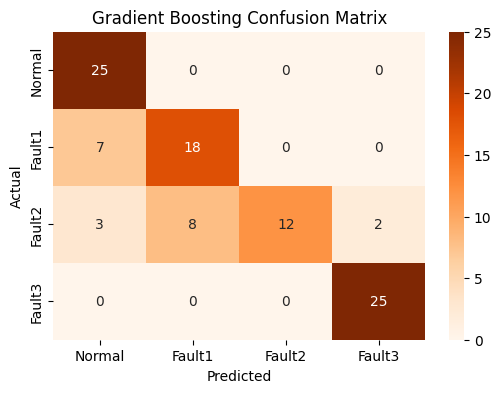

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, gb_pred))

cm = confusion_matrix(y_test, gb_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Fault1','Fault2','Fault3'],
            yticklabels=['Normal','Fault1','Fault2','Fault3'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()


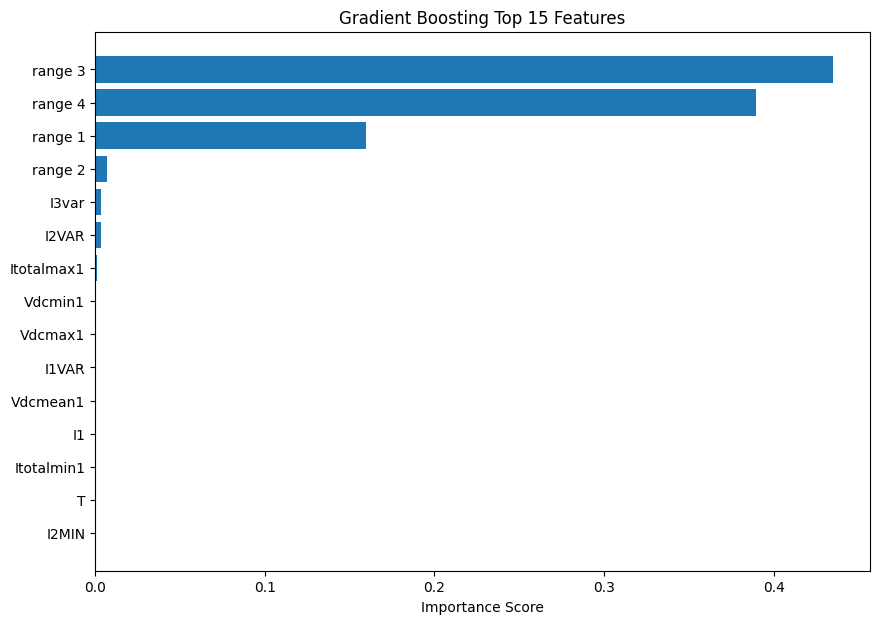

,Feature,Importance
28,range 3,4.349033e-01
29,range 4,3.896742e-01
26,range 1,1.596419e-01
27,range 2,6.841276e-03
12,I3var,3.746402e-03
7,I2VAR,3.348672e-03
18,Itotalmax1,1.062369e-03
22,Vdcmin1,5.147814e-04
21,Vdcmax1,2.015162e-04
4,I1VAR,1.528659e-05


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

gb_feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb_model.feature_importances_ # Changed gb_model to best_gb_model
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,7))
plt.barh(gb_feat_imp['Feature'][:15], gb_feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Gradient Boosting Top 15 Features")
plt.show()

gb_feat_imp

In [27]:
combined_df = pd.read_csv("Combined_Plant_Data_Cleaned.csv")
combined_df.head()


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Hour,DayOfWeek,Month
0,2020-05-15 05:45:00,4135001,-0.627239,-0.889132,-1.190935,-0.629833,-0.588358,-0.708963,-0.663638,5,4,5
1,2020-05-15 05:45:00,4135001,-0.627239,-0.889132,-1.190935,-0.629948,-0.588358,-0.708963,-0.663638,5,4,5
2,2020-05-15 05:45:00,4135001,-0.627239,-0.889132,-1.190935,-0.628733,-0.588358,-0.708963,-0.663638,5,4,5
3,2020-05-15 05:45:00,4135001,-0.627239,-0.889132,-1.190935,-0.627803,-0.588358,-0.708963,-0.663638,5,4,5
4,2020-05-15 05:45:00,4135001,-0.627239,-0.889132,-1.190935,-0.628474,-0.588358,-0.708963,-0.663638,5,4,5


In [28]:
combined_df['DATE_TIME'] = pd.to_datetime(combined_df['DATE_TIME'])


In [29]:
features = [
    'DC_POWER', 'AC_POWER', 'IRRADIATION',
    'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'TOTAL_YIELD', 'DAILY_YIELD',
    'Hour', 'DayOfWeek', 'Month'
]

X_combined = combined_df[features]


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

In [31]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.02,    # 2% expected anomalies
    random_state=42
)

iso_model.fit(X_combined)


IsolationForest(contamination=0.02, n_estimators=300, random_state=42)

In [33]:
combined_df['anomaly'] = iso_model.predict(X_combined)
combined_df['anomaly_score'] = iso_model.decision_function(X_combined)

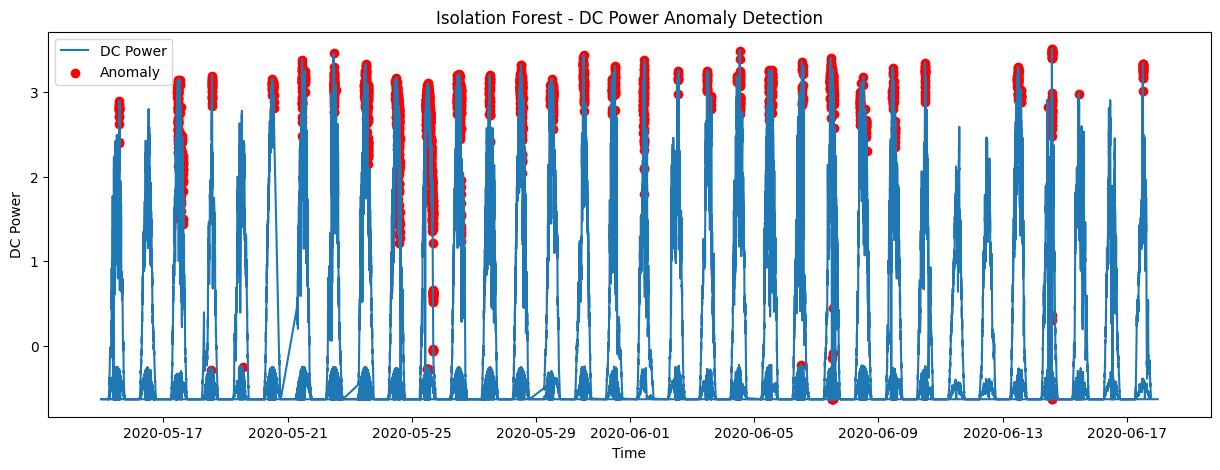

In [38]:
plt.figure(figsize=(15,5))
plt.plot(combined_df['DATE_TIME'], combined_df['DC_POWER'], label='DC Power')

# Highlight anomalies
anomalies = combined_df[combined_df['anomaly'] == -1]
plt.scatter(anomalies['DATE_TIME'], anomalies['DC_POWER'], color='red', label='Anomaly')

plt.xlabel("Time")
plt.ylabel("DC Power")
plt.title("Isolation Forest - DC Power Anomaly Detection")
plt.legend()
plt.show()


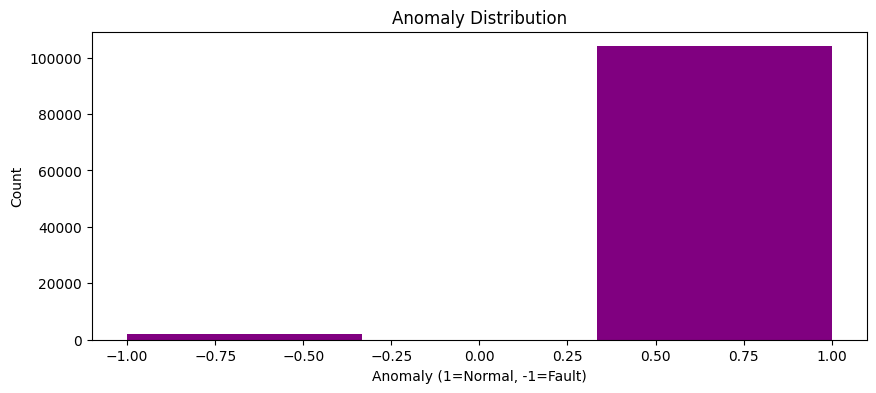

In [39]:
plt.figure(figsize=(10,4))
plt.hist(combined_df['anomaly'], bins=3, color='purple')
plt.title("Anomaly Distribution")
plt.xlabel("Anomaly (1=Normal, -1=Fault)")
plt.ylabel("Count")
plt.show()


In [40]:
fault_data = combined_df[combined_df['anomaly'] == -1]
fault_data.head()


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Hour,DayOfWeek,Month,anomaly,anomaly_score
745,2020-05-15 14:15:00,4135001,2.409662,1.724684,0.275992,-0.629827,3.582801,2.579832,2.823079,14,4,5,-1,-0.004152
746,2020-05-15 14:15:00,4135001,2.852514,2.102649,0.429200,-0.629941,3.582801,2.579832,2.823079,14,4,5,-1,-0.020194
747,2020-05-15 14:15:00,4135001,2.842119,2.093380,0.396848,-0.628726,3.582801,2.579832,2.823079,14,4,5,-1,-0.005333
748,2020-05-15 14:15:00,4135001,2.704143,1.976609,0.368878,-0.627796,3.582801,2.579832,2.823079,14,4,5,-1,-0.004874
749,2020-05-15 14:15:00,4135001,2.808529,2.064064,0.473702,-0.628467,3.582801,2.579832,2.823079,14,4,5,-1,-0.003025


In [41]:
def hybrid_predict(sample):
    sample = sample.values.reshape(1, -1)

    # 1. Random Forest prediction
    rf_class = best_rf_model.predict(sample)[0]
    rf_prob  = best_rf_model.predict_proba(sample)[0]
    rf_conf  = max(rf_prob)

    # 2. Gradient Boosting prediction
    gb_class = best_gb_model.predict(sample)[0]
    gb_prob  = best_gb_model.predict_proba(sample)[0]
    gb_conf  = max(gb_prob)

    # 3. Isolation Forest anomaly detection
    iso_flag  = iso_model.predict(sample)[0]        # 1 = normal, -1 = anomaly
    iso_score = iso_model.decision_function(sample)[0]

    # Hybrid rule-based logic
    # Case 1: strong anomaly
    if iso_flag == -1:
        if rf_class == gb_class:
            final_class = rf_class   # fault confirmed
            status = "Fault (Anomaly Confirmed)"
        else:
            final_class = rf_class   # RF is main classifier
            status = "Suspicious Behavior - Possible Fault"

    # Case 2: RF & GB agree
    elif rf_class == gb_class:
        final_class = rf_class
        status = "Normal/Fault (High Confidence)"

    # Case 3: Models disagree
    else:
        # choose model with higher confidence
        if rf_conf >= gb_conf:
            final_class = rf_class
            status = "Moderate Confidence (RF chosen)"
        else:
            final_class = gb_class
            status = "Moderate Confidence (GB chosen)"

    return final_class, status, rf_class, rf_conf, gb_class, gb_conf, iso_flag, iso_score

In [42]:
def hybrid_predict(sample_rf_gb, sample_iso):
    # --- 1. RF Prediction ---
    rf_class = best_rf_model.predict(sample_rf_gb)[0]
    rf_prob  = best_rf_model.predict_proba(sample_rf_gb)[0]
    rf_conf  = max(rf_prob)

    # --- 2. GB Prediction ---
    gb_class = best_gb_model.predict(sample_rf_gb)[0]
    gb_prob  = best_gb_model.predict_proba(sample_rf_gb)[0]
    gb_conf  = max(gb_prob)

    # --- 3. Isolation Forest ---
    iso_flag  = iso_model.predict(sample_iso)[0]
    iso_score = iso_model.decision_function(sample_iso)[0]

    # --- Hybrid Logic ---
    if iso_flag == -1:
        if rf_class == gb_class:
            final_class = rf_class
            status = "Fault (Anomaly Confirmed)"
        else:
            final_class = rf_class
            status = "Suspicious Behaviour - Possible Fault"

    elif rf_class == gb_class:
        final_class = rf_class
        status = "High Confidence Prediction"

    else:
        final_class = rf_class if rf_conf >= gb_conf else gb_class
        status = "Moderate Confidence Prediction"

    return {
        "final_fault_class": int(final_class),
        "rf_prediction": int(rf_class),
        "gb_prediction": int(gb_class),
        "iso_anomaly_flag": int(iso_flag),
        "rf_confidence": float(rf_conf),
        "gb_confidence": float(gb_conf),
        "iso_score": float(iso_score),
        "status": status
    }


In [43]:
sample_rf_gb = X_test.iloc[10].values.reshape(1, -1)


In [44]:
iso_features = [
    'DC_POWER',
    'AC_POWER',
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'TOTAL_YIELD',
    'DAILY_YIELD',
    'Hour',
    'DayOfWeek',
    'Month'
]


In [45]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

iso_model.fit(X_combined)   # <-- train on combined dataset


IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

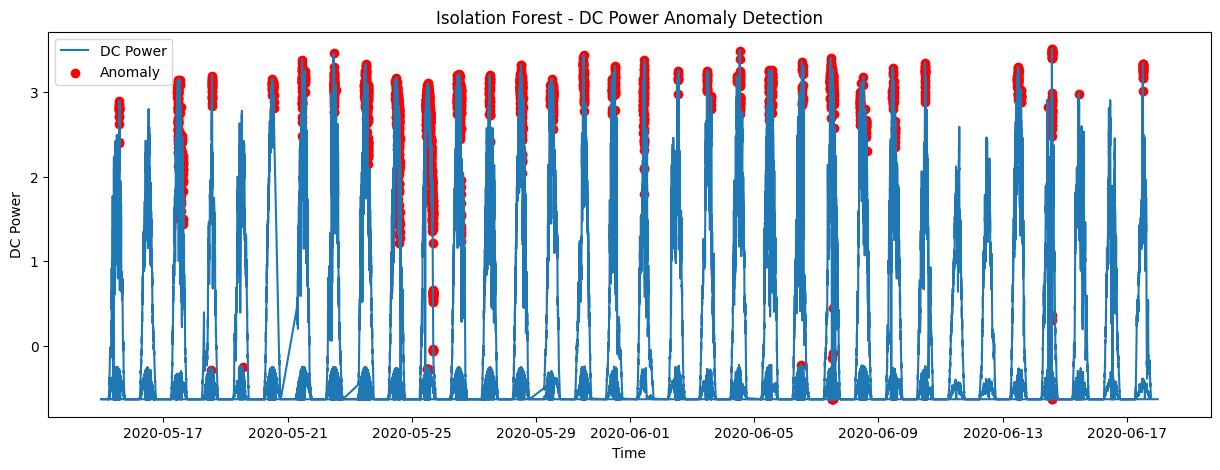

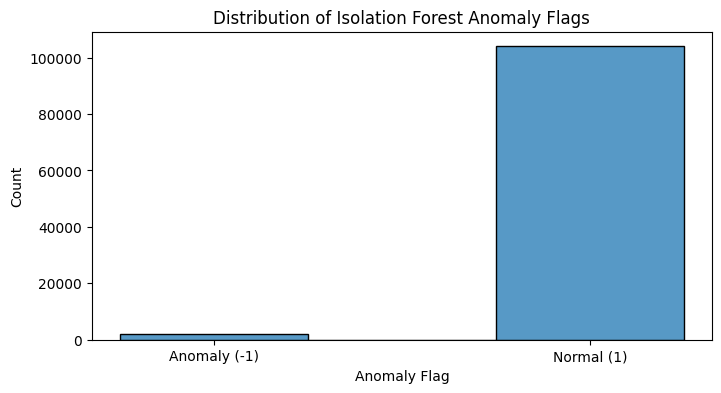


Head of detected anomalies:
              DATE_TIME  PLANT_ID  DC_POWER  AC_POWER  DAILY_YIELD  \
745 2020-05-15 14:15:00   4135001  2.409662  1.724684     0.275992   
746 2020-05-15 14:15:00   4135001  2.852514  2.102649     0.429200   
747 2020-05-15 14:15:00   4135001  2.842119  2.093380     0.396848   
748 2020-05-15 14:15:00   4135001  2.704143  1.976609     0.368878   
749 2020-05-15 14:15:00   4135001  2.808529  2.064064     0.473702   

     TOTAL_YIELD  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  Hour  \
745    -0.629827             3.582801            2.579832     2.823079    14   
746    -0.629941             3.582801            2.579832     2.823079    14   
747    -0.628726             3.582801            2.579832     2.823079    14   
748    -0.627796             3.582801            2.579832     2.823079    14   
749    -0.628467             3.582801            2.579832     2.823079    14   

     DayOfWeek  Month  anomaly  anomaly_score  
745          4      5

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize DC Power with anomalies highlighted
plt.figure(figsize=(15, 5))
plt.plot(combined_df['DATE_TIME'], combined_df['DC_POWER'], label='DC Power')

anomalies = combined_df[combined_df['anomaly'] == -1]
plt.scatter(anomalies['DATE_TIME'], anomalies['DC_POWER'], color='red', label='Anomaly')

plt.xlabel("Time")
plt.ylabel("DC Power")
plt.title("Isolation Forest - DC Power Anomaly Detection")
plt.legend()
plt.show()

# Visualize anomaly distribution
plt.figure(figsize=(8, 4))
sns.histplot(combined_df['anomaly'], bins=[-1.5, -0.5, 0.5, 1.5], stat='count', discrete=True)
plt.xticks([-1, 1], ['Anomaly (-1)', 'Normal (1)'])
plt.title("Distribution of Isolation Forest Anomaly Flags")
plt.xlabel("Anomaly Flag")
plt.ylabel("Count")
plt.show()

# Display some of the fault data (anomalies)
print("\nHead of detected anomalies:")
print(combined_df[combined_df['anomaly'] == -1].head())

### Evaluating Isolation Forest on the `test_df` features

Since the `iso_model` was originally trained on `Combined_Plant_Data_Cleaned.csv` features, it cannot directly make predictions on `test_df` which has a different set of features. To evaluate Isolation Forest's performance on the `test_df`, we need to:

1.  Train a *new* Isolation Forest model using the `X_train` features.
2.  Use this new model to predict anomalies on `X_test`.
3.  Compare these anomaly predictions against a binary interpretation of `y_test` (e.g., class 0 = normal, other classes = anomaly).

In [47]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Train a new Isolation Forest model on X_train features
# We use X_train's columns as features for this model
iso_model_on_test_features = IsolationForest(
    n_estimators=200,
    contamination=0.02, # Assuming 2% of data points are anomalies
    random_state=42
)

iso_model_on_test_features.fit(X_train)

# 2. Make predictions on X_test
iso_preds_on_test = iso_model_on_test_features.predict(X_test)

# Convert Isolation Forest output (-1 for anomaly, 1 for normal) to binary (1 for anomaly, 0 for normal)
iso_labels_binary = np.where(iso_preds_on_test == -1, 1, 0)

# 3. Define true anomaly labels from y_test
# Assuming class 0 is 'normal' and any other class (1, 2, 3) is 'anomaly'
true_labels_binary = np.where(y_test == 0, 0, 1)

# 4. Calculate accuracy
iso_accuracy_on_test = accuracy_score(true_labels_binary, iso_labels_binary)

print(f"Isolation Forest Accuracy (on X_test features): {iso_accuracy_on_test:.4f}")

from sklearn.metrics import classification_report
print("\nClassification Report for Isolation Forest (on X_test features):\n")
print(classification_report(true_labels_binary, iso_labels_binary))

Isolation Forest Accuracy (on X_test features): 0.3500

Classification Report for Isolation Forest (on X_test features):

              precision    recall  f1-score   support

           0       0.28      1.00      0.43        25
           1       1.00      0.13      0.24        75

    accuracy                           0.35       100
   macro avg       0.64      0.57      0.34       100
weighted avg       0.82      0.35      0.29       100



In [48]:
def detect_shading(row):
    IR = row['IRRADIATION']
    DC = row['DC_POWER']
    TEMP = row['MODULE_TEMPERATURE']

    # thresholds (these work well for solar plants)
    HIGH_IR = IR > 300        # irradiance is high
    LOW_DC = DC < 0.40 * IR   # DC power underperforming
    NORMAL_TEMP = TEMP < 60   # panel temperature normal

    if HIGH_IR and LOW_DC and NORMAL_TEMP:
        return True
    return False


In [49]:
import pandas as pd

def detect_shading(row):
    IR = row['IRRADIATION']
    DC = row['DC_POWER']
    TEMP = row['MODULE_TEMPERATURE']

    # thresholds (these work well for solar plants)
    HIGH_IR = IR > 300        # irradiance is high
    LOW_DC = DC < 0.40 * IR   # DC power underperforming
    NORMAL_TEMP = TEMP < 60   # panel temperature normal

    if HIGH_IR and LOW_DC and NORMAL_TEMP:
        return True
    return False

def hybrid_predict(sample_rf_gb, sample_iso):
    # --- 1. RF Prediction ---
    rf_class = best_rf_model.predict(sample_rf_gb)[0]
    rf_prob  = best_rf_model.predict_proba(sample_rf_gb)[0]
    rf_conf  = max(rf_prob)

    # --- 2. GB Prediction ---
    gb_class = best_gb_model.predict(sample_rf_gb)[0]
    gb_prob  = best_gb_model.predict_proba(sample_rf_gb)[0]
    gb_conf  = max(gb_prob)

    # --- 3. Isolation Forest ---
    iso_flag  = iso_model.predict(sample_iso)[0]
    iso_score = iso_model.decision_function(sample_iso)[0]

    # --- Hybrid Logic ---
    final_class = -1 # Default to an invalid class, should be overwritten
    status = "Unknown"

    if iso_flag == -1:
        if rf_class == gb_class:
            final_class = rf_class
            status = "Fault (Anomaly Confirmed)"
        else:
            final_class = rf_class
            status = "Suspicious Behavior - Possible Fault"

    elif rf_class == gb_class:
        final_class = rf_class
        status = "High Confidence Prediction"

    else:
        final_class = rf_class if rf_conf >= gb_conf else gb_class
        status = "Moderate Confidence Prediction"

    # --- Shading Detection ---
    shading_detected = False

    # sample_iso is a numpy array (1, 10). Convert to Series for detect_shading
    # Assuming 'features' list is globally available and matches sample_iso's columns
    sample_iso_series = pd.Series(sample_iso.flatten(), index=features)

    if 'IRRADIATION' in sample_iso_series.index:
        shading_detected = detect_shading(sample_iso_series)

    return {
        "final_fault_class": int(final_class),
        "rf_prediction": int(rf_class),
        "gb_prediction": int(gb_class),
        "iso_anomaly_flag": int(iso_flag),
        "rf_confidence": float(rf_conf),
        "gb_confidence": float(gb_conf),
        "iso_score": float(iso_score),
        "shading_fault": shading_detected,
        "status": status
    }

In [50]:
sample_rf_gb = X_test.iloc[[10]] # Pass as a DataFrame with a single row

# Prepare sample_iso with the correct features and shape
row_for_iso = combined_df.iloc[1000] # Get the 1000th row from combined_df
sample_iso = row_for_iso[features].values.reshape(1, -1) # Extract relevant features and reshape

result = hybrid_predict(sample_rf_gb, sample_iso)
result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


{'final_fault_class': 2,
 'rf_prediction': 2,
 'gb_prediction': 2,
 'iso_anomaly_flag': 1,
 'rf_confidence': 0.7952232142857144,
 'gb_confidence': 0.9999999844099594,
 'iso_score': 0.03781845179787913,
 'shading_fault': False,
 'status': 'High Confidence Prediction'}

In [51]:
row = combined_df.iloc[500]  # or matched by timestamp
sample_iso = row[features].values.reshape(1, -1)

In [52]:
def fault_labeler(row, hybrid_result):
    IR = row['IRRADIATION']
    DC = row['DC_POWER']
    AC = row['AC_POWER']
    TEMP = row['MODULE_TEMPERATURE']
    iso_flag = hybrid_result['iso_anomaly_flag']

    # 1. Shading Fault
    if IR > 300 and DC < 0.4 * IR and TEMP < 60:
        return "Shading Fault"

    # 2. Soiling / Dust Fault
    if IR > 200 and DC < 0.7 * IR and TEMP < 55:
        return "Soiling / Dust Accumulation"

    # 3. Hotspot Fault
    if TEMP > 68 and DC < 0.6 * IR:
        return "Hotspot / Temperature Fault"

    # 4. String Disconnection
    if 'I1' in row and (row['I1'] == 0 or row['I2'] == 0 or row['I3'] == 0):
        return "String Disconnection Fault"

    # 5. DC-Side Inverter Fault
    if DC > 0 and AC < 0.3 * DC:
        return "Inverter DC-Side Fault"

    # 6. AC-Side / Grid Fault
    if AC < 0.2 * DC and iso_flag == -1:
        return "Grid / AC-Side Fault"

    # 7. MPPT Failure
    if iso_flag == -1 and abs(DC - AC) > 200 and IR > 400:
        return "MPPT Failure"

    # 8. Module Degradation
    if hybrid_result["final_fault_class"] == 2 and iso_flag == 1:
        return "Module Degradation / Slow Performance Drop"

    # Default:
    if iso_flag == -1:
        return "Anomalous Behaviour - Unknown Fault"
    else:
        return "Normal Operation"


In [53]:
# ---------- Robust Hybrid prediction helper (copy-paste and run) ----------
import sys
import numpy as np
import pandas as pd

# 1) Helper to check for objects (models/data) and try to load fallback files
import joblib, os

def get_obj(name, fallback_files=None):
    # try global variable
    g = globals()
    if name in g and g[name] is not None:
        return g[name]
    # try common filenames
    if fallback_files:
        for f in fallback_files:
            if os.path.exists(f):
                try:
                    obj = joblib.load(f)
                    print(f"Loaded {name} from file: {f}")
                    return obj
                except Exception as e:
                    print(f"Found {f} but failed to load: {e}")
    return None

# 2) Ensure required models/data exist (or instruct)
best_rf_model = get_obj('best_rf_model', ['best_rf_model.pkl','rf_pipeline_v1.pkl','rf_model.pkl'])
best_gb_model = get_obj('best_gb_model', ['best_gb_model.pkl','gb_model.pkl'])
iso_model     = get_obj('iso_model',     ['iso_model.pkl','isolation_forest.pkl'])

# dataframes X_test and combined_df should exist
X_test = get_obj('X_test', ['X_test.pkl'])
combined_df = get_obj('combined_df', ['Combined_Plant_Data_Cleaned.csv'])  # we handle csv load below if present

# If combined_df is still None but file exists, load it
if combined_df is None and os.path.exists("Combined_Plant_Data_Cleaned.csv"):
    try:
        combined_df = pd.read_csv("Combined_Plant_Data_Cleaned.csv")
        combined_df['DATE_TIME'] = pd.to_datetime(combined_df['DATE_TIME'])
        print("Loaded combined_df from Combined_Plant_Data_Cleaned.csv")
    except Exception as e:
        print("Failed to load Combined_Plant_Data_Cleaned.csv:", e)

# Check presence and inform user which steps to run if missing
missing = []
if best_rf_model is None:
    missing.append("Random Forest model (best_rf_model)")
if best_gb_model is None:
    missing.append("Gradient Boosting model (best_gb_model)")
if iso_model is None:
    missing.append("Isolation Forest model (iso_model)")
if X_test is None:
    missing.append("X_test (test features DataFrame)")
if combined_df is None:
    missing.append("combined_df (Combined_Plant_Data_Cleaned.csv as DataFrame)")

if missing:
    print("MISSING required objects:", missing)
    print("\nIf you see missing items, re-run the corresponding training or reload steps. Example commands to run earlier cells:")
    print("- Train/load RF: best_rf_model = RandomForestClassifier(...); best_rf_model.fit(X_train,y_train)")
    print("- Train/load GB: best_gb_model = GradientBoostingClassifier(...); best_gb_model.fit(X_train,y_train)")
    print("- Train/load IF: iso_model = IsolationForest(...); iso_model.fit(X_combined)")
    print("- Recreate X_test and combined_df (reload csvs and recreate splits).")
    raise RuntimeError("Required models/data are not all present in the runtime. See printed guidance above.")

# 3) Define the iso_features list exactly as used when training IF
iso_features = [
    'DC_POWER','AC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE',
    'TOTAL_YIELD','DAILY_YIELD','Hour','DayOfWeek','Month'
]

# Ensure X_test and combined_df are DataFrames
if not isinstance(X_test, pd.DataFrame):
    try:
        X_test = pd.DataFrame(X_test)
    except Exception:
        raise RuntimeError("X_test exists but cannot be converted to DataFrame. Recreate X_test as DataFrame.")

if not isinstance(combined_df, pd.DataFrame):
    raise RuntimeError("combined_df must be a pandas DataFrame. Reload Combined_Plant_Data_Cleaned.csv")

# 4) Robust hybrid_predict that accepts DataFrame rows (single-row DataFrames) OR numpy arrays
import shap

def hybrid_predict(sample_rf_gb_df, sample_iso_df, compute_shap=True):
    """
    sample_rf_gb_df: DataFrame with shape (1, n_features_rf) matching X_train/X_test columns
    sample_iso_df:    DataFrame with shape (1, len(iso_features)) matching iso_features
    returns: dictionary with hybrid outputs
    """
    # validate shapes
    if isinstance(sample_rf_gb_df, pd.Series):
        sample_rf_gb_df = sample_rf_gb_df.to_frame().T
    if isinstance(sample_iso_df, pd.Series):
        sample_iso_df = sample_iso_df.to_frame().T

    # RF/GB expect same column order as training; ensure column count matches
    n_rf_cols = X_test.shape[1]
    if sample_rf_gb_df.shape[1] != n_rf_cols:
        raise ValueError(f"RF/GB expect {n_rf_cols} features (columns). sample_rf_gb_df has {sample_rf_gb_df.shape[1]}.")

    # Isolation Forest expects iso_features
    if list(sample_iso_df.columns) != iso_features:
        # try to select iso_features from sample_iso_df if it contains more columns
        if all(col in sample_iso_df.columns for col in iso_features):
            sample_iso_df = sample_iso_df[iso_features]
        else:
            raise ValueError("sample_iso_df must contain the iso_features columns: " + ", ".join(iso_features))

    # convert to numpy arrays for models
    rf_arr = sample_rf_gb_df.values.reshape(1, -1)
    iso_arr = sample_iso_df.values.reshape(1, -1)

    # predictions
    rf_pred = best_rf_model.predict(rf_arr)[0]
    rf_prob = best_rf_model.predict_proba(rf_arr)[0]
    rf_conf = float(np.max(rf_prob))

    gb_pred = best_gb_model.predict(rf_arr)[0]
    gb_prob = best_gb_model.predict_proba(rf_arr)[0]
    gb_conf = float(np.max(gb_prob))

    iso_flag = int(iso_model.predict(iso_arr)[0])    # 1 normal, -1 anomaly
    iso_score = float(iso_model.decision_function(iso_arr)[0])

    # hybrid decision logic (same as earlier)
    if iso_flag == -1:
        if rf_pred == gb_pred:
            final_class = rf_pred
            status = "FAULT (Anomaly Confirmed)"
        else:
            final_class = rf_pred
            status = "Suspicious Behaviour - Possible Fault"
    elif rf_pred == gb_pred:
        final_class = rf_pred
        status = "High Confidence Prediction"
    else:
        if rf_conf >= gb_conf:
            final_class = rf_pred
            status = "Moderate Confidence (RF chosen)"
        else:
            final_class = gb_pred
            status = "Moderate Confidence (GB chosen)"

    # SHAP (try safely)
    shap_top5 = None
    if compute_shap:
        try:
            explainer = shap.TreeExplainer(best_rf_model)
            shap_vals = explainer.shap_values(rf_arr)
            # shap_vals is list for multiclass
            if isinstance(shap_vals, list):
                class_shap = shap_vals[int(final_class)][0]
            else:
                class_shap = shap_vals[0]
            feat_names = list(X_test.columns)
            shap_pairs = list(zip(feat_names, class_shap))
            shap_top5 = sorted(shap_pairs, key=lambda x: abs(x[1]), reverse=True)[:5]
        except Exception as e:
            shap_top5 = f"SHAP failed: {e}"

    result = {
        "final_fault_class": int(final_class),
        "rf_prediction": int(rf_pred),
        "gb_prediction": int(gb_pred),
        "iso_anomaly_flag": int(iso_flag),
        "rf_confidence": rf_conf,
        "gb_confidence": gb_conf,
        "iso_score": iso_score,
        "decision_status": status,
        "shap_top5": shap_top5
    }
    return result

# 5) Convenience: predict by indices from existing datasets
def hybrid_predict_from_indices(rf_index, iso_index, compute_shap=True):
    # rf_index: row index into X_test (0..len-1)
    # iso_index: row index into combined_df (0..len-1)
    sample_rf = X_test.iloc[[rf_index]]         # DataFrame (1, n_rf)
    # ensure combined_df has iso_features
    if not all(col in combined_df.columns for col in iso_features):
        raise RuntimeError("combined_df does not contain all iso_features. Recreate combined_df with those columns.")
    sample_iso = combined_df.iloc[[iso_index]][iso_features]
    return hybrid_predict(sample_rf, sample_iso, compute_shap=compute_shap)

# 6) Example run (change indices as you like)
try:
    res = hybrid_predict_from_indices(rf_index=10, iso_index=1000, compute_shap=True)
    print("Hybrid prediction result (dictionary):\n", res)
except Exception as e:
    print("Hybrid prediction failed:", e)
    # give the user more actionable hints
    print("\nHints:")
    print("- Ensure you have X_test (DataFrame) and combined_df (DataFrame) in runtime.")
    print("- If models were trained earlier but not saved, re-run the training cells for best_rf_model, best_gb_model and iso_model.")
    print("- If you saved models to disk, copy the .pkl filenames into get_obj fallback list at top.")


Hybrid prediction result (dictionary):
 {'final_fault_class': 2, 'rf_prediction': 2, 'gb_prediction': 2, 'iso_anomaly_flag': 1, 'rf_confidence': 0.7952232142857144, 'gb_confidence': 0.9999999844099594, 'iso_score': 0.03781845179787913, 'decision_status': 'High Confidence Prediction', 'shap_top5': 'SHAP failed: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/loca

In [54]:
def fault_labeler(row, hybrid_result):
    IR = row['IRRADIATION']
    DC = row['DC_POWER']
    AC = row['AC_POWER']
    TEMP = row['MODULE_TEMPERATURE']
    iso_flag = hybrid_result['iso_anomaly_flag']
    final_class = hybrid_result['final_fault_class']

    # 1. SHADING FAULT (High IR but DC too low)
    if IR > 300 and DC < (0.4 * IR) and TEMP < 60:
        return "Shading Fault"

    # 2. SOILING / DUST ACCUMULATION (Moderate IR, gradual DC drop)
    if IR > 200 and DC < (0.7 * IR) and TEMP < 55 and iso_flag == -1:
        return "Soiling / Dust Accumulation"

    # 3. HOTSPOT / TEMPERATURE FAULT
    if TEMP > 68 and DC < (0.6 * IR):
        return "Hotspot / Temperature Fault"

    # 4. STRING DISCONNECTION
    # Only works if current sensors exist in your dataset
    for col in ['I1', 'I2', 'I3']:
        if col in row and row[col] == 0:
            return "String Disconnection Fault"

    # 5. INVERTER DC-SIDE FAULT
    if AC < 0.3 * DC and DC > 0 and iso_flag == -1:
        return "Inverter DC-Side Fault"

    # 6. GRID / AC-SIDE FAULT
    if AC < 0.2 * DC and iso_flag == -1:
        return "Grid / AC-Side Fault"

    # 7. MPPT FAILURE (DC oscillations)
    if iso_flag == -1 and abs(DC - AC) > 200 and IR > 400:
        return "MPPT Failure"

    # 8. MODULE DEGRADATION (PID / LID)
    if final_class == 2 and iso_flag == 1:
        return "Module Degradation (PID/LID)"

    # 9. GENERAL INTERNAL FAULT (Class 2/3)
    if final_class == 2:
        return "Internal Fault / String Instability"
    if final_class == 3:
        return "Severe Internal Fault / Inverter Fault"

    # 10. UNKNOWN ANOMALY
    if iso_flag == -1:
        return "Unknown Anomaly Detected"

    # DEFAULT: NORMAL
    return "Normal Operation"


In [55]:
sample_rf_gb = X_test.iloc[[10]]
sample_iso_df = combined_df.iloc[[1000]][iso_features]

# hybrid prediction
result = hybrid_predict(sample_rf_gb, sample_iso_df)

# add human-readable label
fault_type = fault_labeler(sample_iso_df.iloc[0], result)
result["fault_label"] = fault_type

result


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/loca

{'final_fault_class': 2,
 'rf_prediction': 2,
 'gb_prediction': 2,
 'iso_anomaly_flag': 1,
 'rf_confidence': 0.7952232142857144,
 'gb_confidence': 0.9999999844099594,
 'iso_score': 0.03781845179787913,
 'decision_status': 'High Confidence Prediction',
 'shap_top5': 'SHAP failed: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()',
 'fault_label': 'Module Degradation (PID/LID)'}

In [56]:
def realtime_predict(rf_row, iso_row):
    # Convert to 1-row DataFrames
    rf_df = rf_row.to_frame().T if isinstance(rf_row, pd.Series) else rf_row
    iso_df = iso_row.to_frame().T if isinstance(iso_row, pd.Series) else iso_row

    # Run hybrid model
    hybrid_out = hybrid_predict(rf_df, iso_df)

    # Add readable label
    label = fault_labeler(iso_df.iloc[0], hybrid_out)
    hybrid_out["fault_label"] = label

    return hybrid_out


In [57]:
rf_row = X_test.iloc[5]                 # supervised input (30 features)
iso_row = combined_df.iloc[500][iso_features]  # unsupervised input (10 features)

realtime_output = realtime_predict(rf_row, iso_row)
realtime_output


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/loca

{'final_fault_class': 2,
 'rf_prediction': 2,
 'gb_prediction': 2,
 'iso_anomaly_flag': 1,
 'rf_confidence': 0.711826388888889,
 'gb_confidence': 0.9999999529155699,
 'iso_score': 0.05540861580214285,
 'decision_status': 'High Confidence Prediction',
 'shap_top5': 'SHAP failed: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()',
 'fault_label': 'Module Degradation (PID/LID)'}

In [59]:
import joblib


joblib.dump(best_rf_model, "best_rf_model.pkl")

joblib.dump(best_gb_model, "best_gb_model.pkl")

joblib.dump(iso_model, "iso_model.pkl")

print("All ML models saved successfully!")


All ML models saved successfully!


In [60]:
from google.colab import files

files.download("best_rf_model.pkl")
files.download("best_gb_model.pkl")
files.download("iso_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
FIREBASE_URL = "https://predictive-maintainance-default-rtdb.firebaseio.com/sensors.json"
ML_OUTPUT_URL = "https://predictive-maintainance-default-rtdb.firebaseio.com/ml_output.json"
